In [1]:
import hoda
import tensorly as tl
import mne
!pip install line_profiler
%load_ext line_profiler
mne.set_log_level('ERROR')
tl.get_backend()


[notice] A new release of pip is available: 23.2.1 -> 24.0
[notice] To update, run: python3 -m pip install --upgrade pip
The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


'cupy'

In [2]:
from moabb.paradigms import P300
from moabb.datasets import *
from mne.decoding import Scaler

tmin = 0
tmax=0.8
fmin=0.5

fmax = 16
sfreq = 32

paradigm = P300(resample=sfreq, tmin=tmin, tmax=tmax, fmin=fmin, fmax=fmax)
dataset = BNCI2014_008()
epochs, labels, meta = paradigm.get_data(
    dataset=dataset, 
     subjects=[4],
     return_epochs=True
)
session = meta['session'][0]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]
#epochs._data = Scaler(scalings='mean', with_mean=True).fit_transform(epochs._data)

To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.


In [3]:
meta

,subject,session,run
0,4,0,0
1,4,0,0
2,4,0,0
3,4,0,0
4,4,0,0
...,...,...,...
4195,4,0,0
4196,4,0,0
4197,4,0,0
4198,4,0,0


In [4]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl

X = epochs.get_data()
y = labels

X.shape

(4200, 8, 26)

In [5]:
from sklearn.model_selection import StratifiedKFold
from hoda.hoda import BTTDA, InfoBTTDA, HODA, trunc_eigh
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import Scaler
import  warnings
from sklearn.model_selection import GridSearchCV
from hoda.classification import Vectorize
from sklearn.feature_selection import SelectFwe
from sklearn.preprocessing import StandardScaler
import warnings

bttda = InfoBTTDA(
    max_blocks=16,
    info_crit='bic',
    truncate=False,
    hoda_params=dict(
        rank=None,
        max_iter=128,
        tol=1e-12,
        init ='random',
        shrinkage='lw',
        toeplitz=None,
        obj='rt',
        solver='lanczos',
        taper=False,
        extra_train_info=False,
        verbose=True,
       
    ),
    verbose=True,
    extra_train_info=True,
    
)
%env PYTHONWARNINGS=ignore
%lprun -f bttda.fit bttda.fit(X,y, X_test=X, y_test=y)

env: PYTHONWARNINGS=ignore
Fitting block 1/16...
Fitting discriminative tensor model of rank (1, 1)...


  0%|          | 0/128 [00:00<?, ?it/s]

Fitting discriminative tensor model of rank (2, 2)...


  0%|          | 0/128 [00:00<?, ?it/s]

Fitting discriminative tensor model of rank (4, 4)...


...

Fitting discriminative tensor model of rank (4, 4)...


  0%|          | 0/128 [00:00<?, ?it/s]

Fitting discriminative tensor model of rank (8, 8)...


  0%|          | 0/128 [00:00<?, ?it/s]

Timer unit: 1e-09 s

Total time: 33.4378 s
File: /project/src/hoda/hoda.py
Function: fit at line 690

Line #      Hits         Time  Per Hit   % Time  Line Contents
   690                                               def fit(self, X, y=None, X_test=None, y_test=None, blocks=None):
   691         1       3551.0   3551.0      0.0          n_samples, *shape = X.shape
   692                                           
   693         1       1064.0   1064.0      0.0          self.blocks_ = []
   694         1        133.0    133.0      0.0          info_crits = []
   695         2     351383.0 175691.5      0.0          bttda_params = {
   696                                                       k: v
   697         1      94661.0  94661.0      0.0              for k, v in self.get_params().items()
   698                                                       if k in BTTDA().get_params().keys()
   699                                                   }
   700        17       6059.0    356.4 

In [6]:
import pandas as pd

df = pd.DataFrame(bttda.train_info_)
df

,block,rank,F_tr,F_rt,mse,bic
0,1,"(4, 4)",0.041901,0.000261,5.855338e-11,69444.951838
1,2,"(8, 8)",0.010905,0.000290,3.769186e-11,69103.005595
2,3,"(1, 1)",0.010898,0.000290,3.769702e-11,69101.749483
3,4,"(1, 1)",0.010862,0.000290,3.767985e-11,69108.426512
4,5,"(1, 1)",0.010843,0.000290,3.758654e-11,69110.431299
5,6,"(1, 1)",0.010843,0.000290,3.758118e-11,69115.062417
6,7,"(1, 1)",0.010830,0.000290,3.757408e-11,69121.465203
7,8,"(1, 1)",0.010827,0.000291,3.757354e-11,69125.431970
8,9,"(1, 1)",0.010816,0.000291,3.738017e-11,69131.580622
9,10,"(1, 1)",0.010815,0.000291,3.737629e-11,69138.192321


<Axes: xlabel='block', ylabel='bic'>

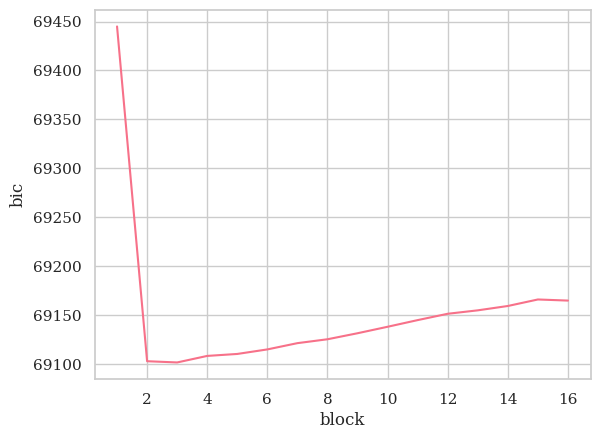

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

n_samples = X.shape[0]
sns.lineplot(data=df, x='block', y=bttda.info_crit)


<Axes: xlabel='block', ylabel='mse'>

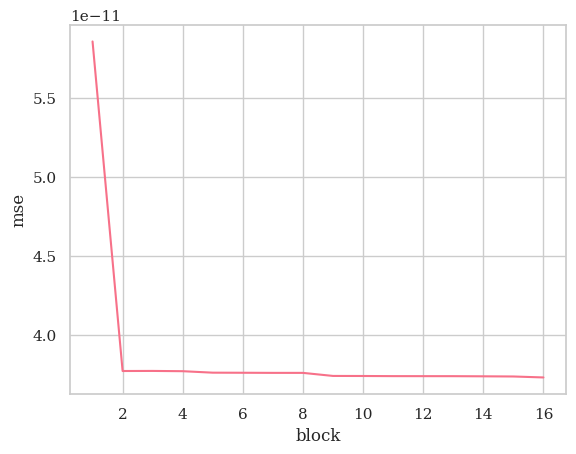

In [8]:
sns.lineplot(data=df, x='block', y='mse')


In [9]:
Xt = bttda.transform(X)

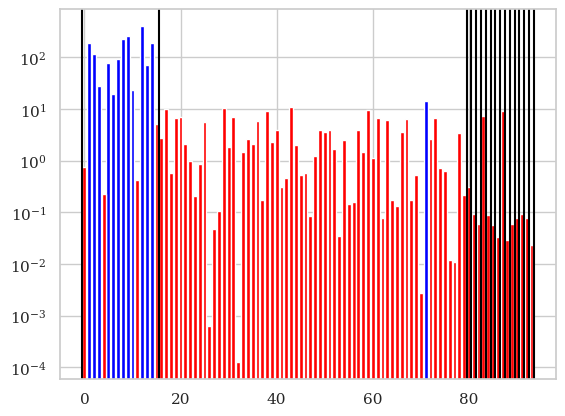

In [10]:
import scipy.stats
import seaborn as sns
import math
import numpy as np

samples = []
for c in bttda.blocks_[0].classes_:
    samples.append(tl.to_numpy(Xt)[y==c])
F,p = scipy.stats.f_oneway(*samples, axis=0)
F = F.flatten()
p = p.flatten()
p = np.nan_to_num(p, nan=1)
fig, ax = plt.subplots(1,1)
sig_idc = p < (0.05/len(p))
plt.bar(np.arange(len(F))[sig_idc],F[sig_idc], color='blue')
plt.bar(np.arange(len(F))[~sig_idc],F[~sig_idc], color='red')
plt.yscale('log')
n_params=0
plt.axvline(n_params-.5, color='black')
for b,block in enumerate(bttda.blocks_):
    n_params+=math.prod(block.rank_)
    plt.axvline(n_params-.5, color='black')

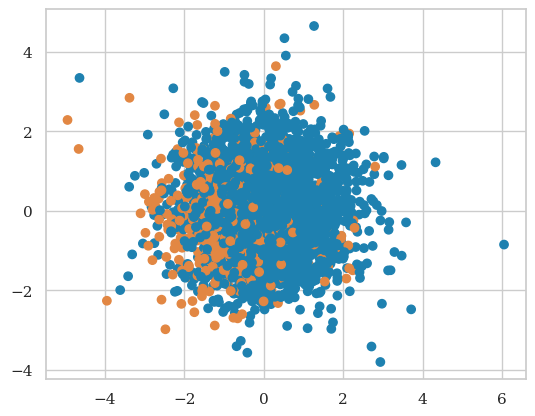

In [11]:
from sklearn.manifold import TSNE
import math
from sklearn.decomposition import PCA
import re, seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap

if Xt.shape[-1] > 1:
    n_components = 2
    decomp  = PCA(n_components=n_components, whiten=True)
    Xt_viz = decomp.fit_transform(tl.to_numpy(Xt[:,sig_idc]))
    
    cmap = {'Target': '#e28743', 'NonTarget': '#1e81b0'}
    c = np.vectorize(cmap.get)(y)    
    fig, ax = plt.subplots(1,1)
    ax.scatter(Xt_viz[:,0], Xt_viz[:,1], c=c)
    ax.set_aspect('equal')


In [12]:
import numpy as np

evokeds = []
vmax=0
for cls in np.unique(labels):
    evoked = epochs[cls].average()
    evokeds.append(evoked)
    vmax= max(vmax, np.max(np.abs(evoked.data))*1.2*1e6)

ts_args=dict(ylim=dict(eeg=[-vmax,vmax]), units=dict(eeg=None))
joint_args=dict(ts_args=ts_args)

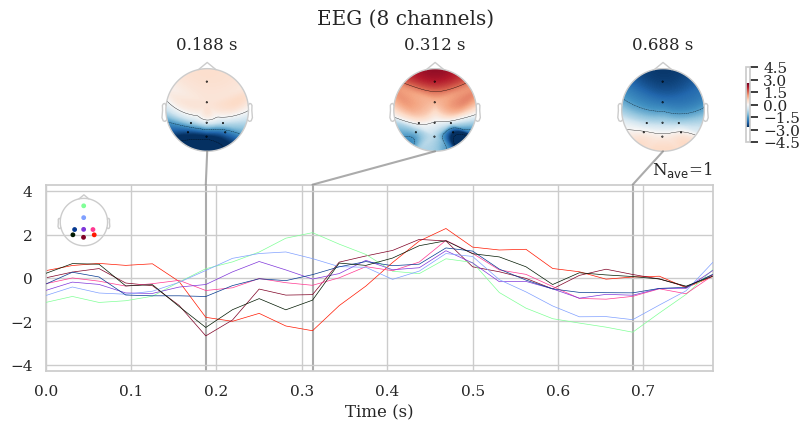

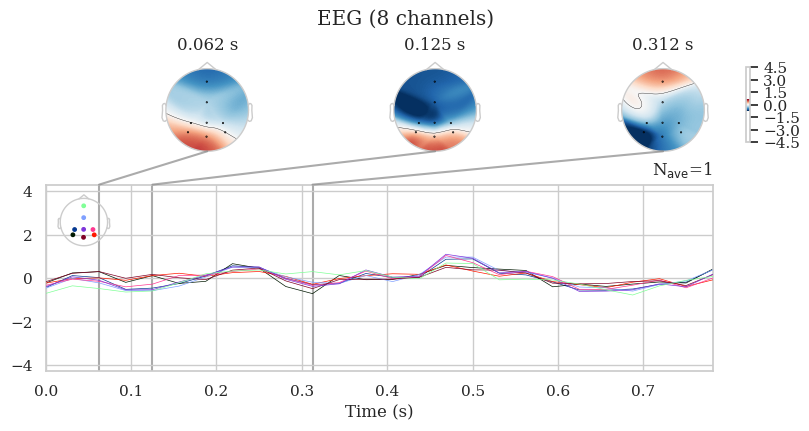

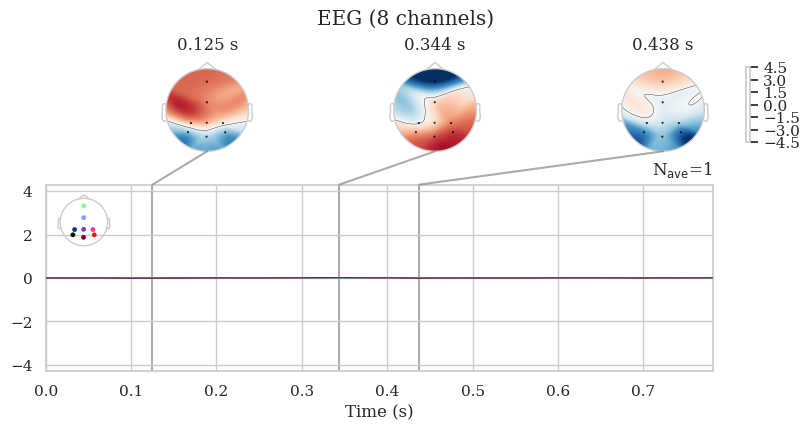

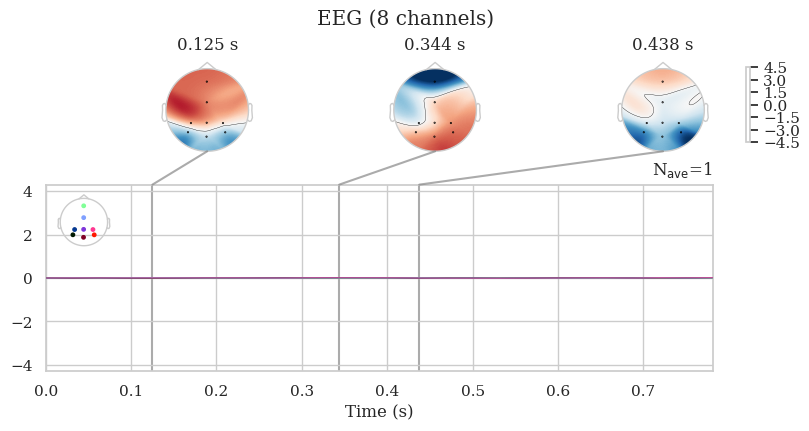

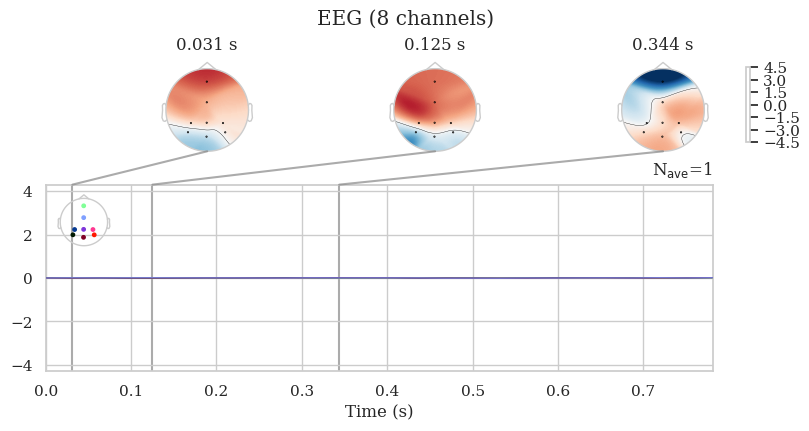

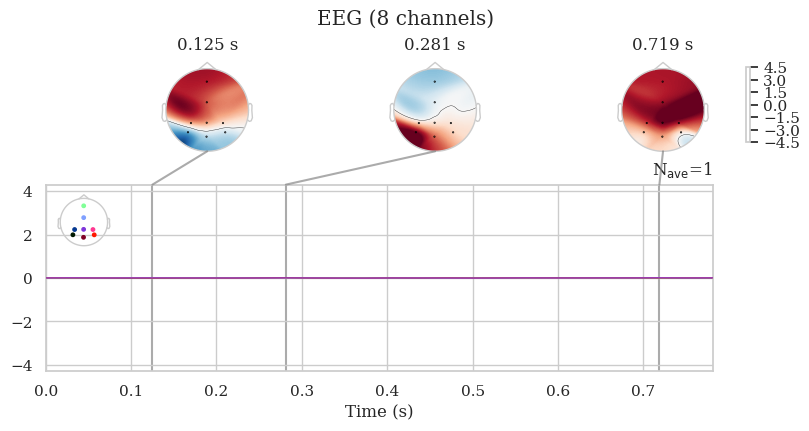

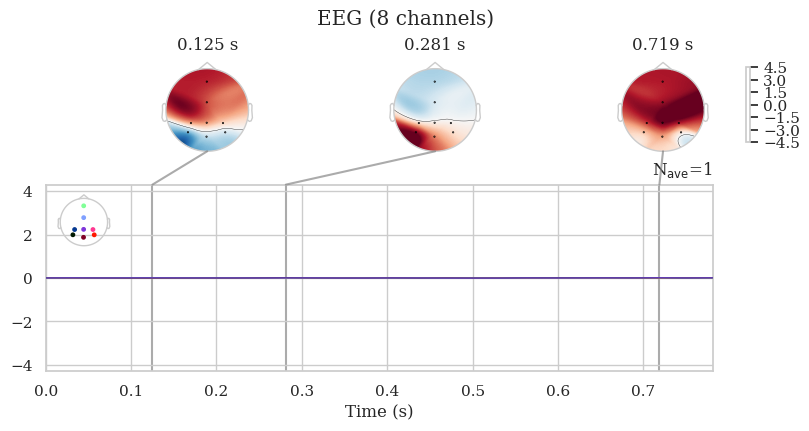

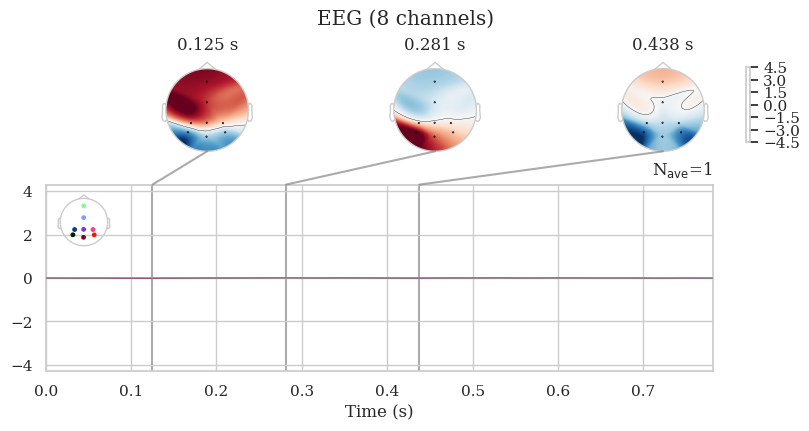

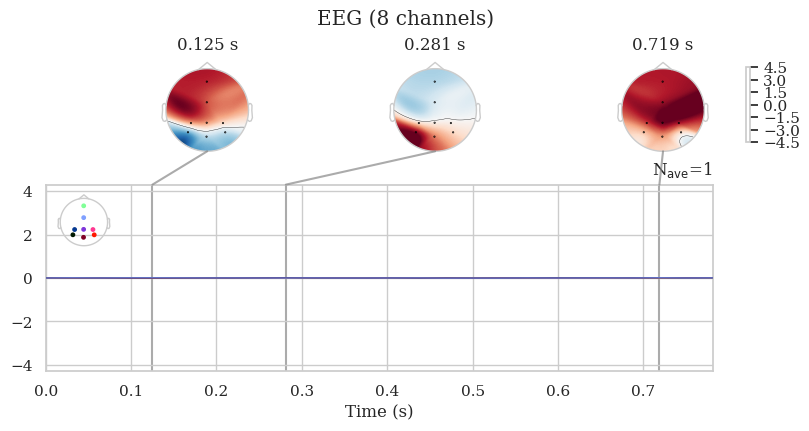

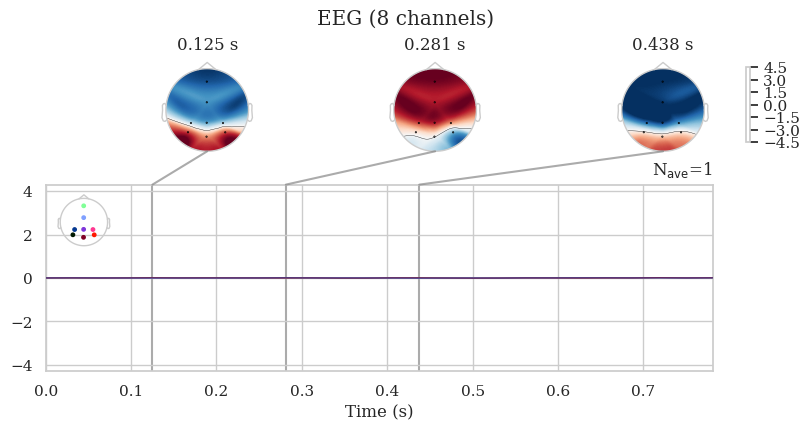

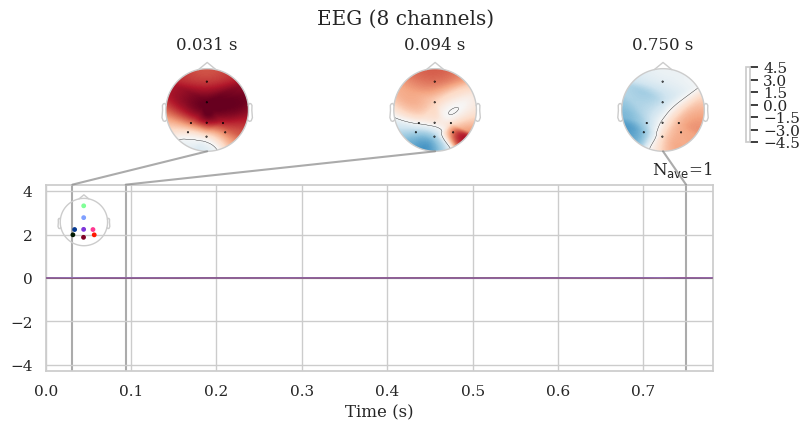

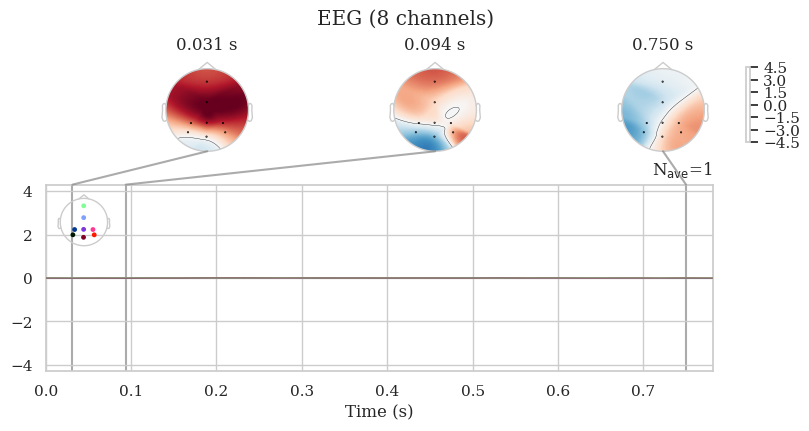

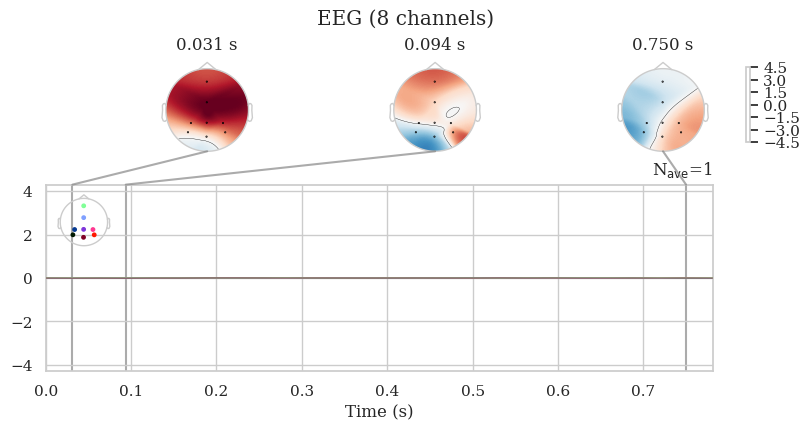

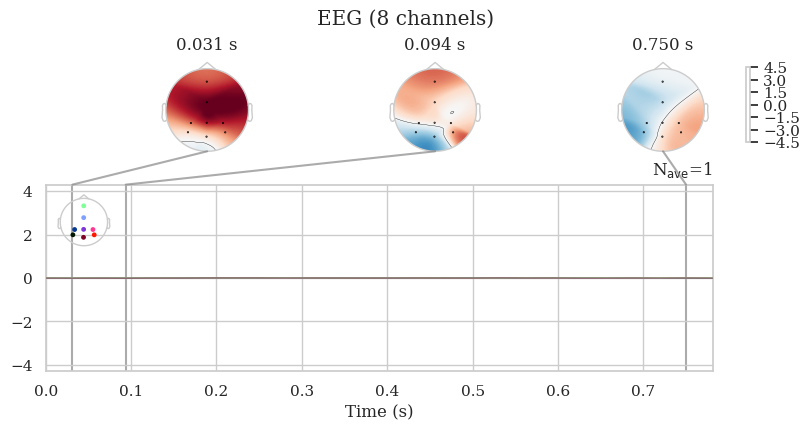

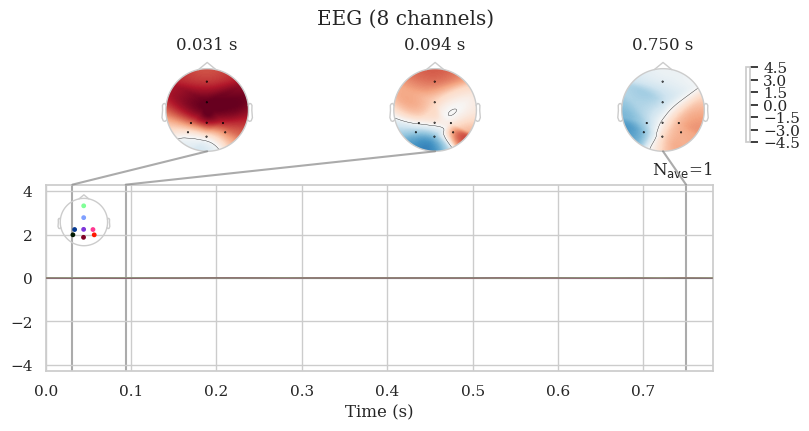

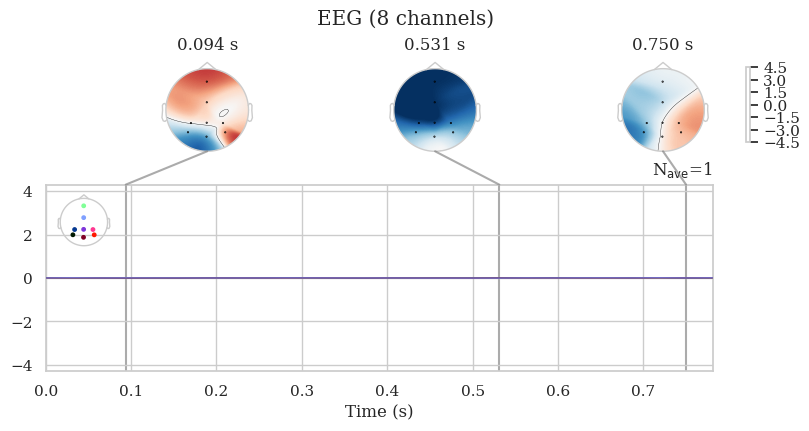

In [13]:
from mne import EvokedArray
for b in bttda.blocks_:
    means_rec = b.means_
    contrast = means_rec[1]-means_rec[0]
    contrast = EvokedArray(tl.to_numpy(contrast), epochs.info, epochs.tmin)
    contrast.plot_joint(**joint_args)

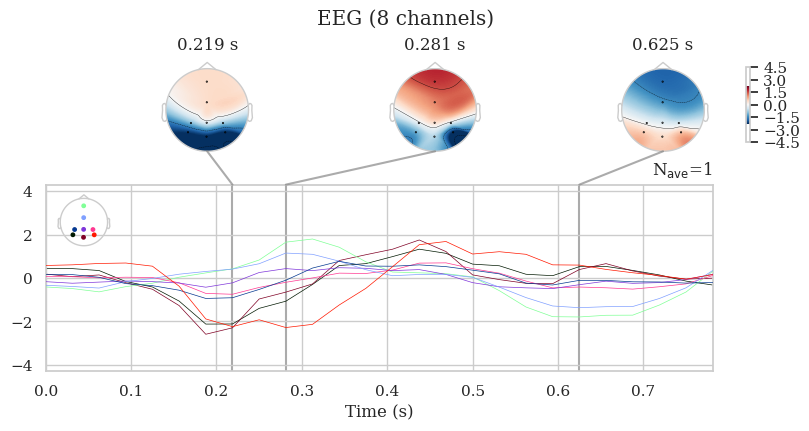

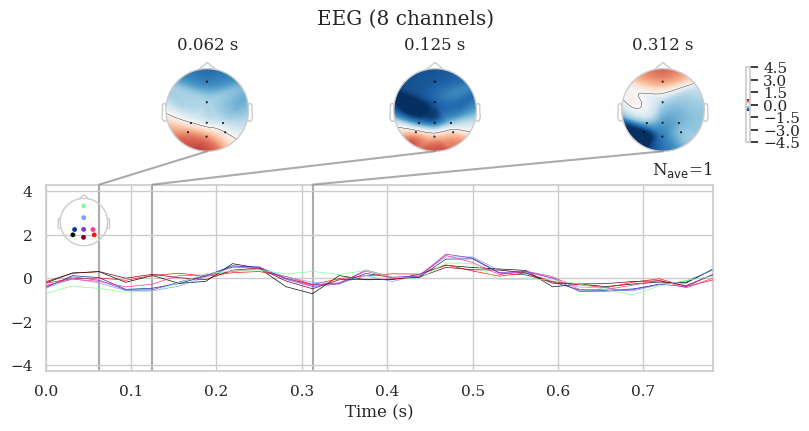

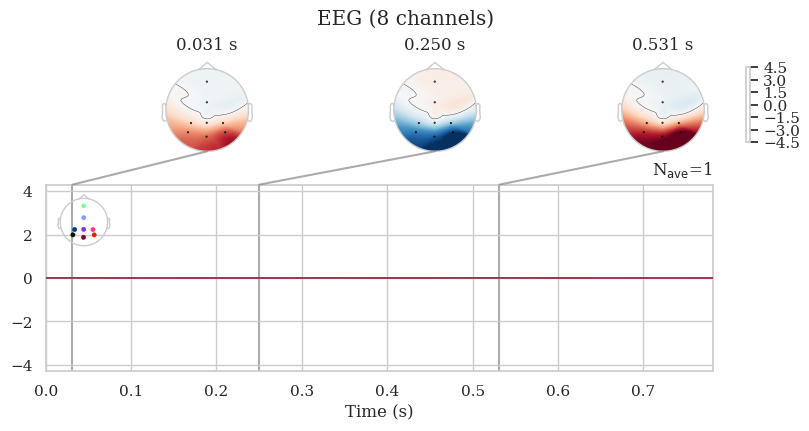

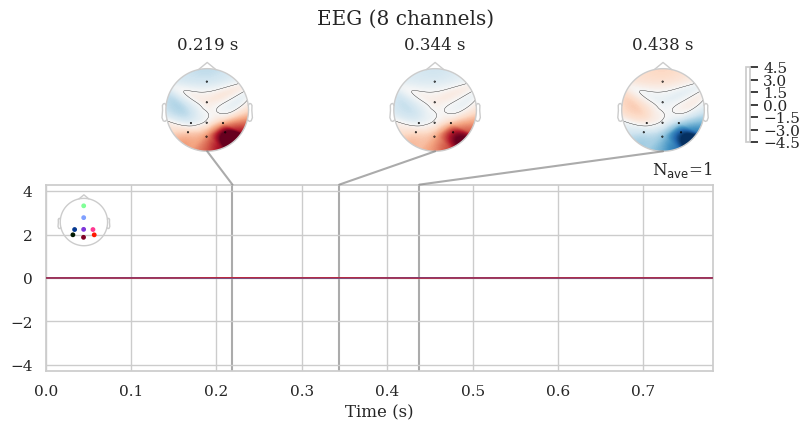

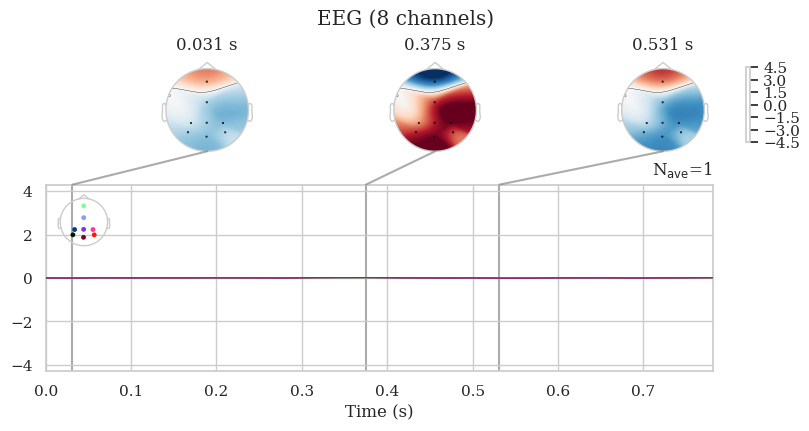

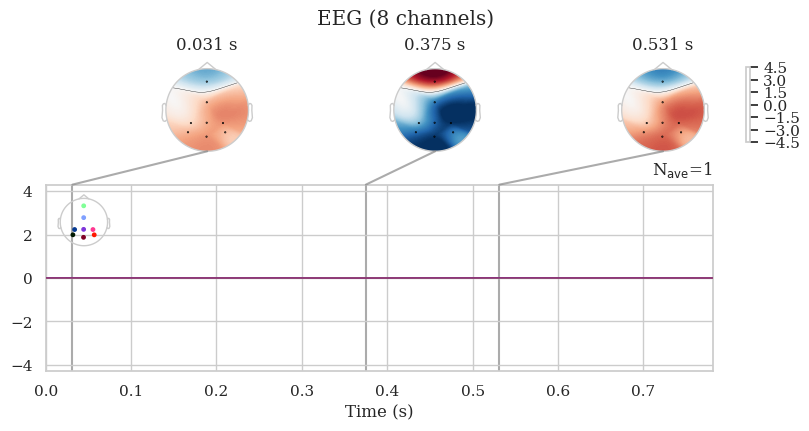

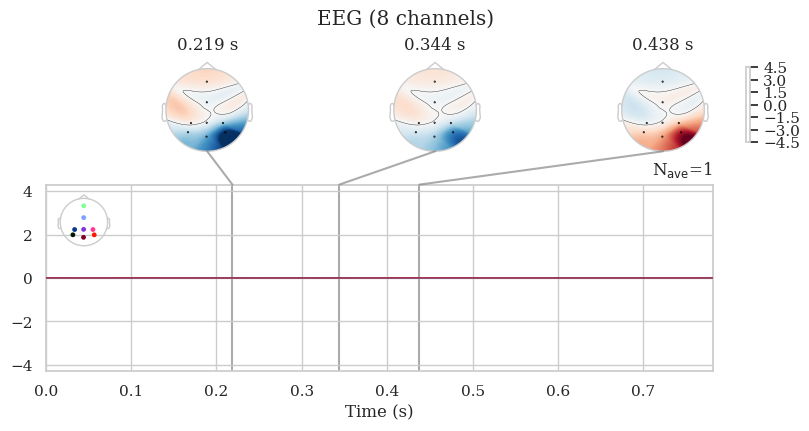

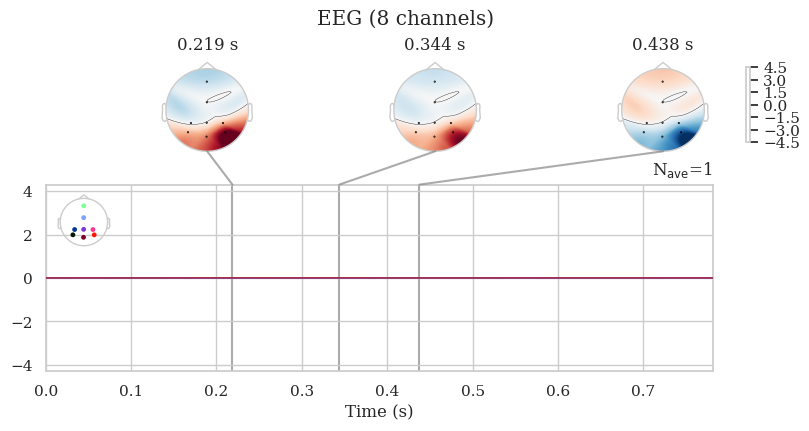

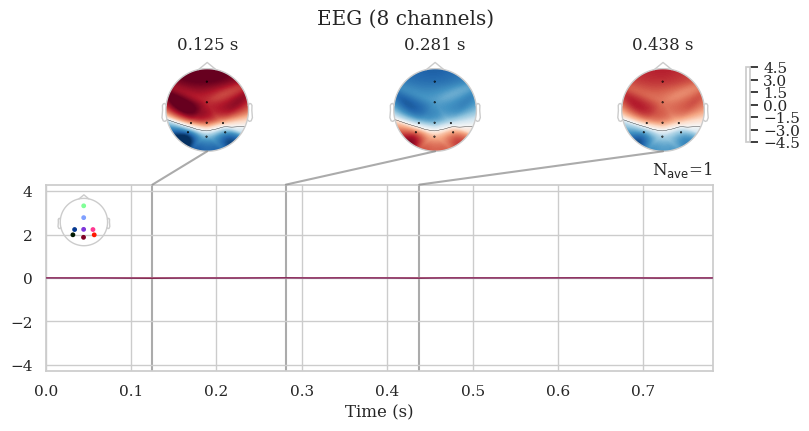

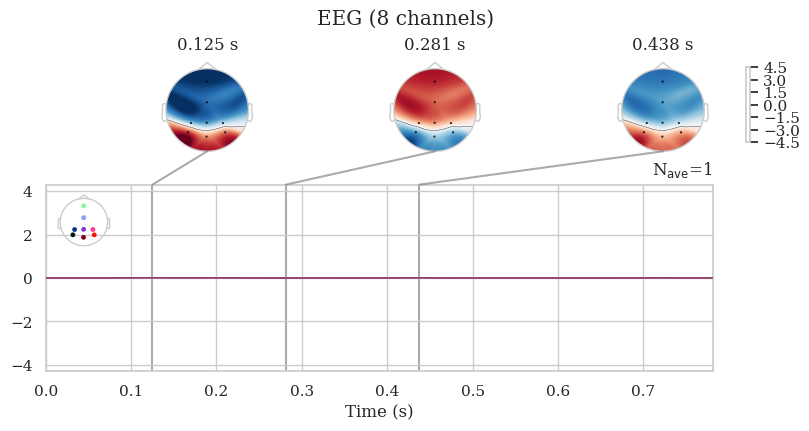

In [14]:
from mne import EvokedArray
for b in bttda.blocks_[:10]:
    means_rec = b.inv_transform(b.transform(b.means_))
    contrast = means_rec[1]-means_rec[0]
    contrast = EvokedArray(tl.to_numpy(contrast), epochs.info, epochs.tmin)
    contrast.plot_joint(**joint_args)

In [15]:
X_rec = bttda.inv_transform(Xt)
epochs_rec = epochs.copy()
epochs_rec._data = tl.to_numpy(X_rec)
evokeds_rec = []
for cls in np.unique(labels):
    evoked_rec = epochs_rec[cls].average()
    evokeds_rec.append(evoked_rec)
    #if len(evoked_rec.ch_names) > 1:
    #    evoked_rec.plot_joint(title=cls,**joint_args)
    #else:
    #    evoked_rec.plot(**ts_args)

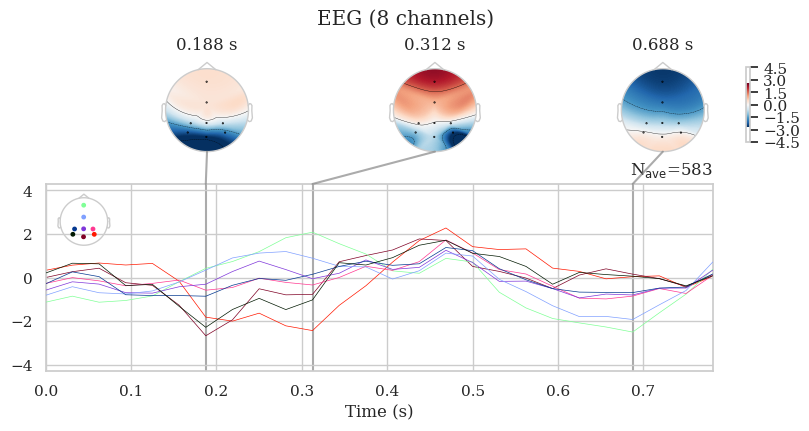

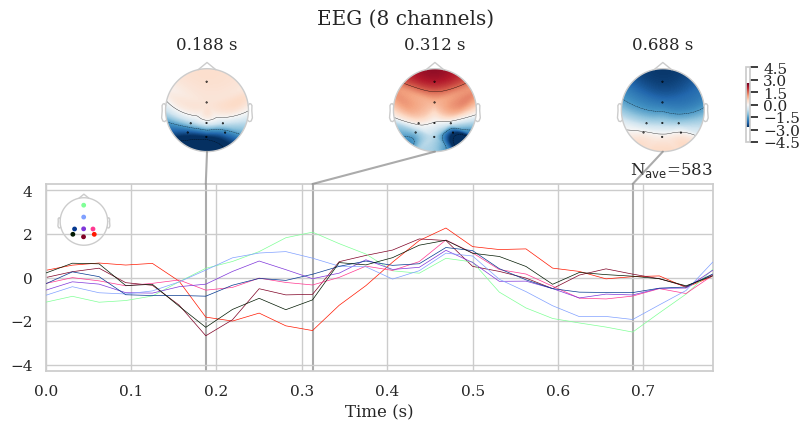

In [16]:
from mne import combine_evoked
contrast = combine_evoked(evokeds, weights=[-1,1])
_ = contrast.plot_joint(**joint_args)
contrast_rec = combine_evoked(evokeds_rec, weights=[-1,1])
_ = contrast_rec.plot_joint(**joint_args)


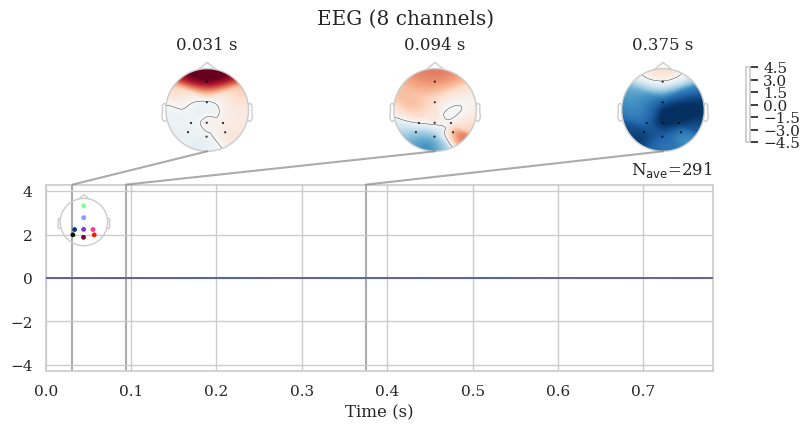

In [17]:
rec_diff = combine_evoked([contrast, contrast_rec], weights=[1,-1])
_ = rec_diff.plot_joint(**joint_args)

In [18]:
Xt[:,0]

array([-6.63160051e-07, -4.44728770e-07,  1.09724475e-06, ...,
       -3.08332090e-07,  1.54744250e-06, -3.26460982e-06])